In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
features = ['ndvi_noir_rgb_method', 'gndvi_noir_rgb_method']
output_variable = 'GYLD_kg_m3'

Text(0.5, 1.0, 'Train vs Test Yield Distribution')

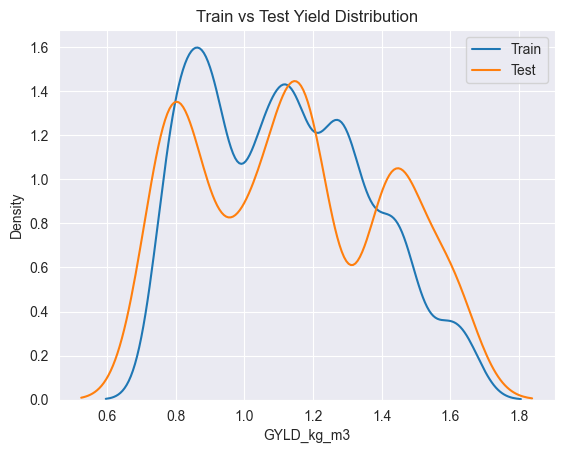

In [3]:
# Loading saved training test
train_df = pd.read_excel("data/stratified_train_test_datasets.xlsx", sheet_name='Train')
test_df = pd.read_excel("data/stratified_train_test_datasets.xlsx", sheet_name='Test')

sns.kdeplot(train_df[output_variable], label='Train')
sns.kdeplot(test_df[output_variable], label='Test')
plt.legend()
plt.title("Train vs Test Yield Distribution")

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

scaler_X = StandardScaler()
scaler_y = RobustScaler()

# Fit on training features and yield only
scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[output_variable]])

train_df_scaled = train_df.copy()
test_df_scaled  = test_df.copy()

# --- Scaled features and target variable---
train_df_scaled[features] = scaler_X.transform(train_df[features])
train_df_scaled[output_variable] = scaler_y.transform(train_df[[output_variable]])

test_df_scaled[features] = scaler_X.transform(test_df[features])
test_df_scaled[output_variable] = scaler_y.transform(test_df[[output_variable]])

In [5]:

num_na_rows = train_df_scaled.isna().any(axis=1).sum()
print(f"train_df_scaled Rows with at least one NaN: {num_na_rows}")

num_na_rows = test_df_scaled.isna().any(axis=1).sum()
print(f"test_df_scaled Rows with at least one NaN: {num_na_rows}")


train_df_scaled Rows with at least one NaN: 0
test_df_scaled Rows with at least one NaN: 0


In [6]:
# print(X_test_scaled.shape)

In [7]:
# num_na_rows =np.isnan(X_train_scaled).any().sum()
# print(f"X_train_scaled Rows with at least one NaN: {num_na_rows}")
#
# num_na_rows = np.isnan(y_train_scaled).any().sum()
# print(f"y_train_scaled Rows with at least one NaN: {num_na_rows}")

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
def train_data(model, model_train_loader, num_epochs, learning_rate, weight_decay, hyper_param_criterion_method, file_save_name, early_stopping = False):
    best_train_loss  = float('inf')
    patience = 20
    counter = 0

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )
    if hyper_param_criterion_method == "MSE":
        criterion = nn.MSELoss()
    else:
        criterion = nn.SmoothL1Loss(beta=1)

    total_loss = []
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in model_train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            # Gradient clipping (prevents exploding gradients)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        avg_loss = train_loss / len(model_train_loader.dataset)
        total_loss.append(avg_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_loss:.5f}")

        if train_loss < best_train_loss:
            best_train_loss = train_loss
            if file_save_name != "":
                torch.save(model.state_dict(), file_save_name)
            counter = 0
        elif early_stopping:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break
    return total_loss


In [10]:
from sklearn.metrics import  mean_squared_error

def evaluate_model(model, val_loader, output_variable_scaler, doInverseTransformScale = False, plot_pred_vs_true = False):

    model.eval()  # set model to evaluation mode
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_hat = model(X_batch)

            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    if doInverseTransformScale:
        y_true = output_variable_scaler.inverse_transform(y_true)
        y_pred = output_variable_scaler.inverse_transform(y_pred)

    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    if plot_pred_vs_true:
        plt.figure(figsize=(8,6))
        plt.scatter(y_true, y_pred, alpha=0.7)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')
        plt.xlabel("Actual Yield")
        plt.ylabel("Predicted Yield")
        plt.title("LSTM Predictions vs Actual")
        plt.show()

    return r2, mse

K-fold cross validation

In [11]:
# from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
plot_ids = train_df['plot_id'].unique()
yield_per_plot = train_df.groupby('plot_id')[output_variable].first().values

y_bins = pd.qcut(yield_per_plot, q=5, labels=False)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [12]:
from helper import make_progressive_windows
from model_definitions import GRUModel
from vi_dataset import VIDataset

window_size = 30
pad_value = -99

def k_fold_cross_validation(batch_size, k_fold_epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(plot_ids, y_bins)):
        print(f"Fold {fold+1}")

        train_plots = plot_ids[train_idx]
        val_plots   = plot_ids[val_idx]

        train_df_fold = train_df[train_df['plot_id'].isin(train_plots)]
        val_df_fold   = train_df[train_df['plot_id'].isin(val_plots)]

        # Scaling
        scaler_X_fold = StandardScaler()
        scaler_y_fold = RobustScaler()

        scaler_X_fold.fit(train_df_fold[features])
        scaler_y_fold.fit(train_df_fold[[output_variable]])

        train_df_fold_scaled = train_df_fold.copy()
        val_df_fold_scaled  = val_df_fold.copy()

        train_df_fold_scaled[features] = scaler_X_fold.transform(train_df_fold[features])
        train_df_fold_scaled[output_variable] = scaler_y_fold.transform(train_df_fold[[output_variable]])

        val_df_fold_scaled[features] = scaler_X_fold.transform(val_df_fold[features])
        val_df_fold_scaled[output_variable] = scaler_y_fold.transform(val_df_fold[[output_variable]])

        X_train_fold, y_train_fold = make_progressive_windows(
            dataframe=train_df_fold_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

        X_val_fold, y_val_fold = make_progressive_windows(
            dataframe=val_df_fold_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

        train_dataset_fold = VIDataset(X_train_fold, y_train_fold)
        val_dataset_fold = VIDataset(X_val_fold, y_val_fold)

        train_loader_fold  = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
        val_loader_fold    = DataLoader(val_dataset_fold, batch_size=batch_size, shuffle=False)

        model = GRUModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                         output_size= 1, dropout=dropout, bidirectional = bidirectional).to(device)

        train_data(
            model = model,
            model_train_loader= train_loader_fold,
            num_epochs = k_fold_epochs,
            learning_rate = learning_rate,
            weight_decay = weight_decay,
            hyper_param_criterion_method = hyper_param_criterion_method,
            file_save_name=""
        )

        r2, mse = evaluate_model(
            model = model,
            val_loader = val_loader_fold,
            output_variable_scaler=scaler_y_fold)

        r2_scores.append(r2)
        print(f"Fold {fold+1} R²: {r2:.4f}")

    mean_r2 = np.mean(r2_scores)
    print(f"\n✅ Mean R² across folds: {mean_r2:.4f}")
    return mean_r2

In [13]:
import optuna
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader

search_space = {
    "hidden_size": [8, 16, 32 , 64],
    "num_layers": [1, 2, 3],
    "dropout": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    "lr":  [0.00001, 0.0001, 0.001, 0.01],
    "batch_size": [8, 16, 32, 64],
}

tuning_epochs = 500

def objective(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = k_fold_cross_validation(
        batch_size= batch_size,
        k_fold_epochs=tuning_epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2


C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# sampler = optuna.samplers.GridSampler(search_space)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)


[I 2025-10-20 07:30:18,935] A new study created in memory with name: no-name-912c66e4-0208-49fa-a57c-8769c3be2b46
C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4561320169192901 and num_layers=1
  warnings.warn(


Fold 1


In [31]:
from helper import make_progressive_windows
from model_definitions import GRUModel
from vi_dataset import VIDataset

def validation_with_test(trial_id, batch_size, epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    X_train_scaled, y_train_scaled = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

    X_test_scaled, y_test_scaled = make_progressive_windows(
        dataframe=test_df_scaled,
        features=features,
        output_variable=output_variable,
        window_size=window_size,
        pad_value=pad_value)

    train_dataset = VIDataset(X_train_scaled, y_train_scaled)
    test_dataset = VIDataset(X_test_scaled, y_test_scaled)

    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader    = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = GRUModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                     output_size= 1, dropout=dropout, bidirectional = bidirectional).to(device)

    train_data(
        model = model,
        model_train_loader= train_loader,
        num_epochs = epochs,
        learning_rate = learning_rate,
        weight_decay = weight_decay,
        hyper_param_criterion_method = hyper_param_criterion_method,
        file_save_name=f"best_model_hyper_param{trial_id}.pth",
        early_stopping=True
    )

    r2, mse = evaluate_model(
        model = model,
        val_loader = test_loader,
        output_variable_scaler=scaler_y)


    print(f" R²: {r2:.4f}")


    return r2

In [32]:
epochs = 1000

def objective2(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = validation_with_test(
        trial_id = trial.number,
        batch_size= batch_size,
        epochs=epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2

In [33]:
study = optuna.create_study(direction="maximize")
study.optimize(objective2, n_trials=30)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

[I 2025-10-20 16:13:28,275] A new study created in memory with name: no-name-ed0b5b45-da11-4998-afc4-3755c1f1a306
C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.32620916799158045 and num_layers=1
  warnings.warn(


Epoch [1/1000] - Train Loss: 0.18065
Epoch [2/1000] - Train Loss: 0.14922
Epoch [3/1000] - Train Loss: 0.13751
Epoch [4/1000] - Train Loss: 0.13197
Epoch [5/1000] - Train Loss: 0.12572
Epoch [6/1000] - Train Loss: 0.12051
Epoch [7/1000] - Train Loss: 0.11760
Epoch [8/1000] - Train Loss: 0.11537
Epoch [9/1000] - Train Loss: 0.11420
Epoch [10/1000] - Train Loss: 0.11253
Epoch [11/1000] - Train Loss: 0.11219
Epoch [12/1000] - Train Loss: 0.11151
Epoch [13/1000] - Train Loss: 0.11041
Epoch [14/1000] - Train Loss: 0.10951
Epoch [15/1000] - Train Loss: 0.10907
Epoch [16/1000] - Train Loss: 0.10862
Epoch [17/1000] - Train Loss: 0.10799
Epoch [18/1000] - Train Loss: 0.10754
Epoch [19/1000] - Train Loss: 0.10654
Epoch [20/1000] - Train Loss: 0.10620
Epoch [21/1000] - Train Loss: 0.10585
Epoch [22/1000] - Train Loss: 0.10538
Epoch [23/1000] - Train Loss: 0.10493
Epoch [24/1000] - Train Loss: 0.10410
Epoch [25/1000] - Train Loss: 0.10364
Epoch [26/1000] - Train Loss: 0.10348
Epoch [27/1000] - Tra

[I 2025-10-20 16:16:15,249] Trial 0 finished with value: -0.19398486614227295 and parameters: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.32620916799158045, 'lr': 0.00012410741709790242, 'weight_decay': 2.3290885336163458e-07, 'batch_size': 16}. Best is trial 0 with value: -0.19398486614227295.


Epoch [554/1000] - Train Loss: 0.01845
Early stopping triggered.
 R²: -0.1940
Epoch [1/1000] - Train Loss: 0.15961
Epoch [2/1000] - Train Loss: 0.13500
Epoch [3/1000] - Train Loss: 0.12853
Epoch [4/1000] - Train Loss: 0.12180
Epoch [5/1000] - Train Loss: 0.12019
Epoch [6/1000] - Train Loss: 0.11936
Epoch [7/1000] - Train Loss: 0.11625
Epoch [8/1000] - Train Loss: 0.11416
Epoch [9/1000] - Train Loss: 0.11495
Epoch [10/1000] - Train Loss: 0.11233
Epoch [11/1000] - Train Loss: 0.11054
Epoch [12/1000] - Train Loss: 0.11067
Epoch [13/1000] - Train Loss: 0.11057
Epoch [14/1000] - Train Loss: 0.10884
Epoch [15/1000] - Train Loss: 0.10914
Epoch [16/1000] - Train Loss: 0.10803
Epoch [17/1000] - Train Loss: 0.10512
Epoch [18/1000] - Train Loss: 0.10387
Epoch [19/1000] - Train Loss: 0.10432
Epoch [20/1000] - Train Loss: 0.10440
Epoch [21/1000] - Train Loss: 0.10345
Epoch [22/1000] - Train Loss: 0.10232
Epoch [23/1000] - Train Loss: 0.10042
Epoch [24/1000] - Train Loss: 0.10140
Epoch [25/1000] - T

[W 2025-10-20 16:17:13,368] Trial 1 failed with parameters: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.4723912349867646, 'lr': 0.00027322201104178787, 'weight_decay': 8.061897401190501e-06, 'batch_size': 32} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_23780\75512920.py", line 12, in objective2
    mean_r2 = validation_with_test(
              ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_23780\3567785779.py", line 30, in validation_with_test
    train_data(
  File "C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_23780\1672866436.py", line 23, in train_data
    y_pred = model(X_batch)
             ^^^^^^^^^^^^^^
 

KeyboardInterrupt: 

In [ ]:


# model = LSTMModel(input_size=len(features) + 1, hidden_size=16, num_layers=1).to(device)

# without masking feature
# Train R²: 0.7030, Train MSE: 0.0170
# Test R²: 0.1261, Test MSE: 0.0658

# model = LSTMModel(input_size=len(features), hidden_size=8, num_layers=2, dropout=0.3).to(device)
# with mask
# Train R²: 0.6567, Train MSE: 0.0197
# Test R²: 0.1573, Test MSE: 0.0634

# without masking feature
# Train R²: 0.6328, Train MSE: 0.0211
# Test R²: 0.3087, Test MSE: 0.0521


In [27]:
# =============================================
#  Train the best model with best hyper params
# =============================================

best_gru_params = {'hidden_size': 8, 'num_layers': 2, 'dropout': 0.3200550648348224, 'lr': 0.00016797903044174476, 'weight_decay': 0.0001286115107102797, 'batch_size': 64}


best_model = GRUModel(
    input_size=len(features),
    hidden_size=best_gru_params['hidden_size'],
    num_layers=best_gru_params['num_layers'],
    output_size=1,
    dropout=best_gru_params['dropout'],
    bidirectional=False).to(device)

In [20]:
X_train_scaled, y_train_scaled = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

X_test_scaled, y_test_scaled = make_progressive_windows(
    dataframe=test_df_scaled,
    features=features,
    output_variable=output_variable,
    window_size=window_size,
    pad_value=pad_value)

In [21]:
train_dataset = VIDataset(X_train_scaled, y_train_scaled)
test_dataset = VIDataset(X_test_scaled, y_test_scaled)

train_loader  = DataLoader(train_dataset, batch_size=best_gru_params['batch_size'], shuffle=True)
test_loader    = DataLoader(test_dataset, batch_size=best_gru_params['batch_size'], shuffle=False)

In [28]:
epochs = 500
criterion_method="L1Loss"

train_losses = train_data(
            model = best_model,
            model_train_loader= train_loader,
            num_epochs = epochs,
            learning_rate = best_gru_params['lr'],
            weight_decay = best_gru_params['weight_decay'],
            hyper_param_criterion_method = criterion_method,
            file_save_name ="best_model_2.pth",
            early_stopping = True,
        )


Epoch [1/500] - Train Loss: 0.18222
Epoch [2/500] - Train Loss: 0.17592
Epoch [3/500] - Train Loss: 0.17025
Epoch [4/500] - Train Loss: 0.16462
Epoch [5/500] - Train Loss: 0.16120
Epoch [6/500] - Train Loss: 0.15695
Epoch [7/500] - Train Loss: 0.15405
Epoch [8/500] - Train Loss: 0.15025
Epoch [9/500] - Train Loss: 0.14907
Epoch [10/500] - Train Loss: 0.14646
Epoch [11/500] - Train Loss: 0.14417
Epoch [12/500] - Train Loss: 0.14247
Epoch [13/500] - Train Loss: 0.14158
Epoch [14/500] - Train Loss: 0.14111
Epoch [15/500] - Train Loss: 0.13868
Epoch [16/500] - Train Loss: 0.13931
Epoch [17/500] - Train Loss: 0.13852
Epoch [18/500] - Train Loss: 0.13713
Epoch [19/500] - Train Loss: 0.13658
Epoch [20/500] - Train Loss: 0.13610
Epoch [21/500] - Train Loss: 0.13574
Epoch [22/500] - Train Loss: 0.13539
Epoch [23/500] - Train Loss: 0.13427
Epoch [24/500] - Train Loss: 0.13434
Epoch [25/500] - Train Loss: 0.13199
Epoch [26/500] - Train Loss: 0.13217
Epoch [27/500] - Train Loss: 0.13153
Epoch [28/

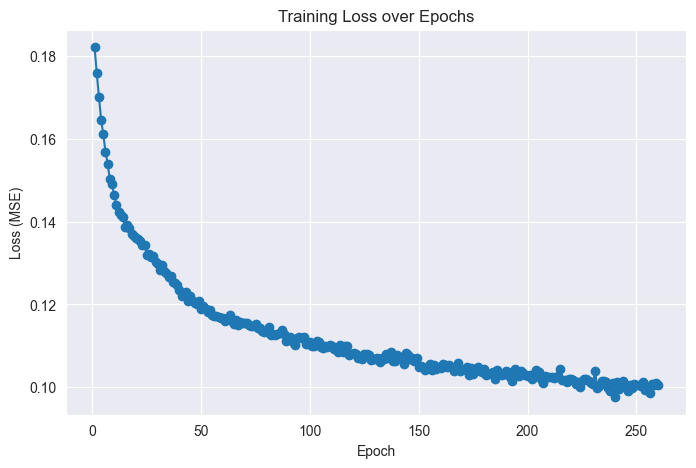

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 260+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

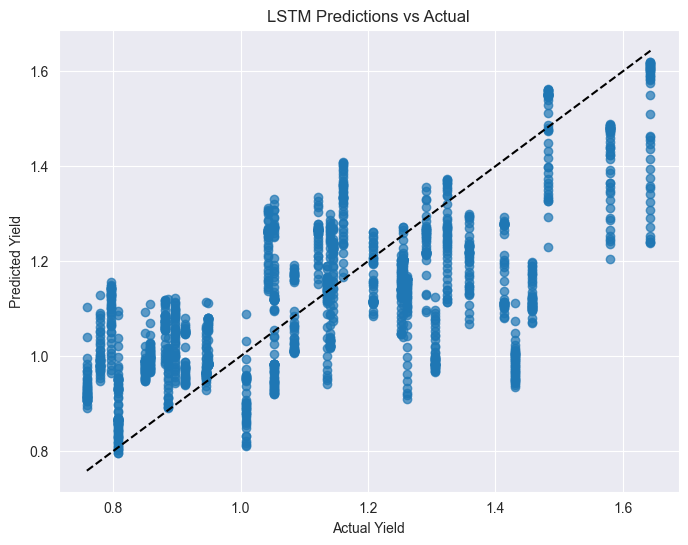

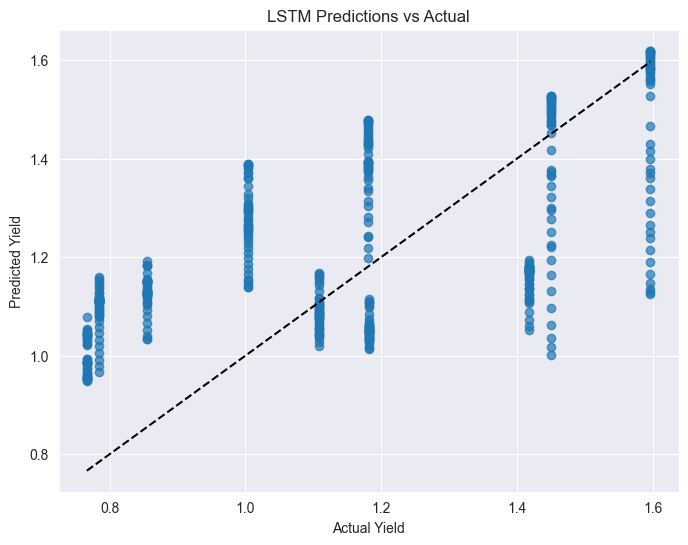

Train R²: 0.4642, Train MSE: 0.0307
Test R²: 0.2968, Test MSE: 0.0529


In [30]:
best_model.load_state_dict(torch.load("best_model_2.pth", map_location=device))

# Training metrics
r2_train, mse_train = evaluate_model(best_model, train_loader, output_variable_scaler=scaler_y, doInverseTransformScale = True,  plot_pred_vs_true=True)
# Test metrics
r2_test, mse_test = evaluate_model(best_model, test_loader, output_variable_scaler=scaler_y, doInverseTransformScale = True,  plot_pred_vs_true=True)

print(f'Train R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}')
print(f'Test R²: {r2_test:.4f}, Test MSE: {mse_test:.4f}')


In [ ]:
# save model
torch.save(best_model.state_dict(), "models/lstm_yield_model_1.pth")
torch.save(best_model, "models/lstm_yield_model_full_1.pth")

# save Scalers for future predictions
import joblib

joblib.dump(scaler_X, "scalers/scaler_X_1.save")
joblib.dump(scaler_y, "scalers/scaler_y_1.save")